# Phase 5 — ResNet34 UNet (Pretrained Encoder)

This notebook trains a UNet with a **pretrained ResNet34 encoder** (ImageNet weights) using `segmentation_models_pytorch`.

**What's different from the custom UNet:**
- Pretrained encoder (transfer learning) — already knows edges, textures, gradients
- Differential learning rate: encoder gets 10x lower LR (fine-tune gently)
- Same training pipeline, augmentations, loss, and metrics as phase5_train.py

**Outputs saved to:** `outputs/phase5_resnet/`

In [0]:
# Install segmentation_models_pytorch (only needed once)
!pip install -q segmentation-models-pytorch

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
petastorm 0.12.1 requires pyspark>=2.1.0, which is not installed.
transformers 4.30.2 requires huggingface-hub<1.0,>=0.14.1, but you have huggingface-hub 1.7.1 which is incompatible.
datasets 2.13.1 requires huggingface-hub<1.0.0,>=0.11.0, but you have huggingface-hub 1.7.1 which is incompatible.

[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [0]:
import subprocess
import sys

PROJECT_ROOT = "Origin"

cmd = [sys.executable, f"{PROJECT_ROOT}/phase5_resnet.py", PROJECT_ROOT]
print("Running:", " ".join(cmd))

proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:
    print(line, end="")
rc = proc.wait()
if rc != 0:
    raise RuntimeError(f"phase5_resnet.py failed with exit code {rc}")

In [0]:
# Print metrics
import json
import os

out_dir = os.path.join(PROJECT_ROOT, "outputs", "phase5_resnet")

for name in ["cracks", "drywall"]:
    mpath = os.path.join(out_dir, f"{name}_metrics.json")
    if os.path.exists(mpath):
        m = json.load(open(mpath))
        print(f"\n{name}: Dice={m['best_val_dice']:.4f}  mIoU={m['best_val_mIoU']:.4f}  best_epoch={m['best_epoch']}")
    else:
        print(f"\n{name}: metrics not found yet")


cracks: Dice=0.7045  mIoU=0.5438  best_epoch=27

drywall: Dice=0.7070  mIoU=0.5468  best_epoch=18



--- cracks examples (orig | GT | pred) ---


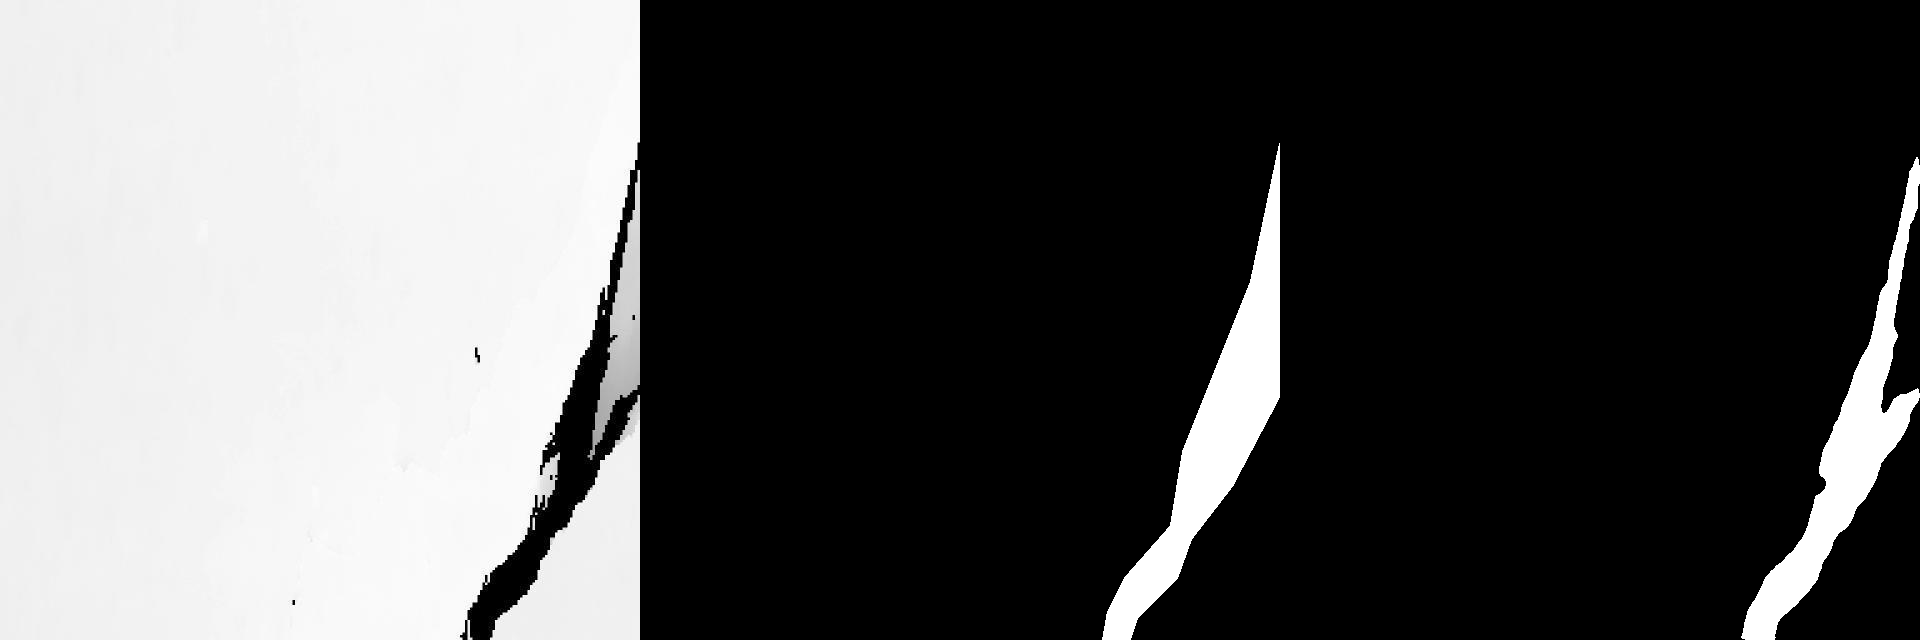

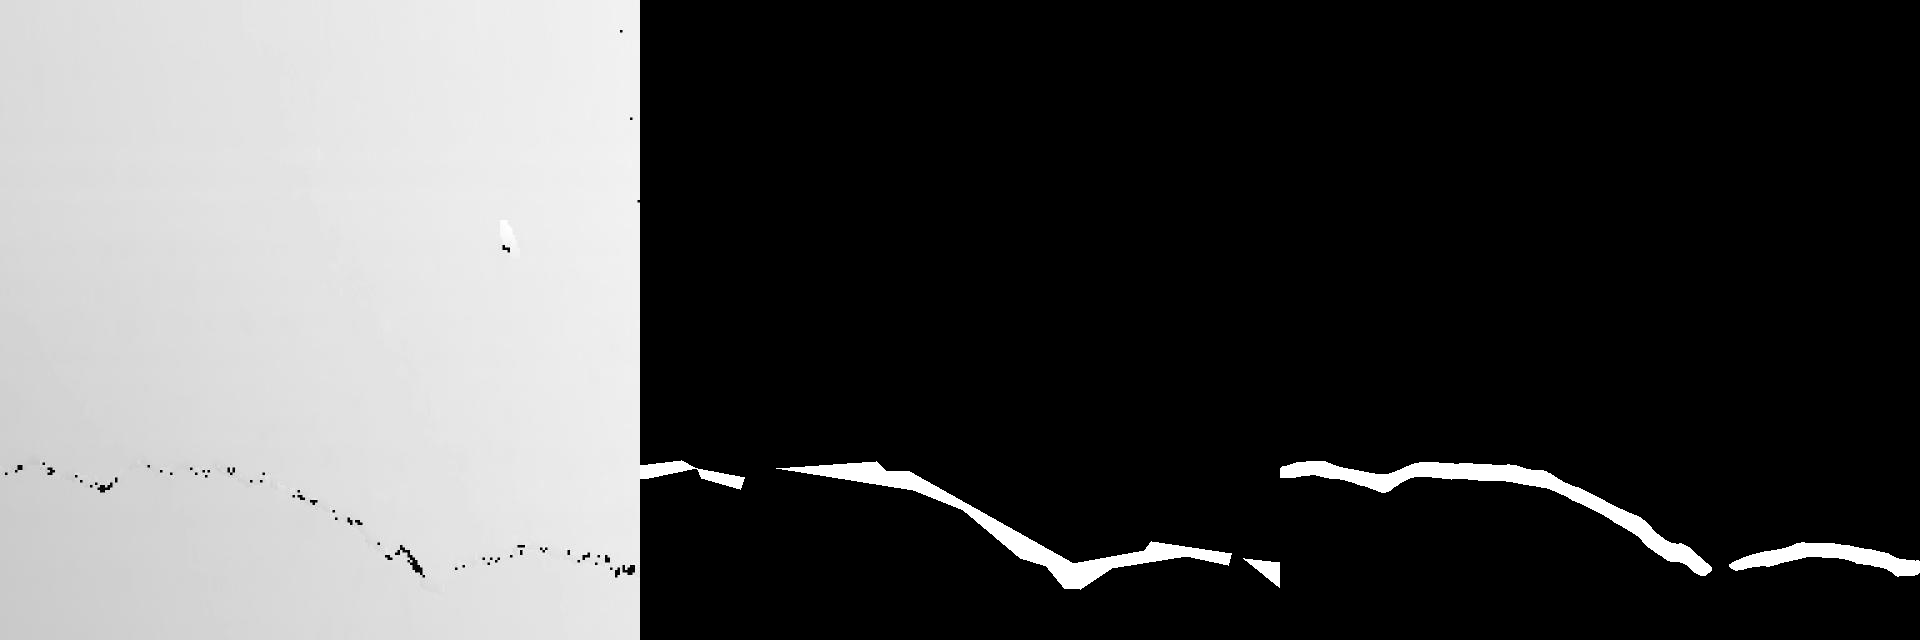

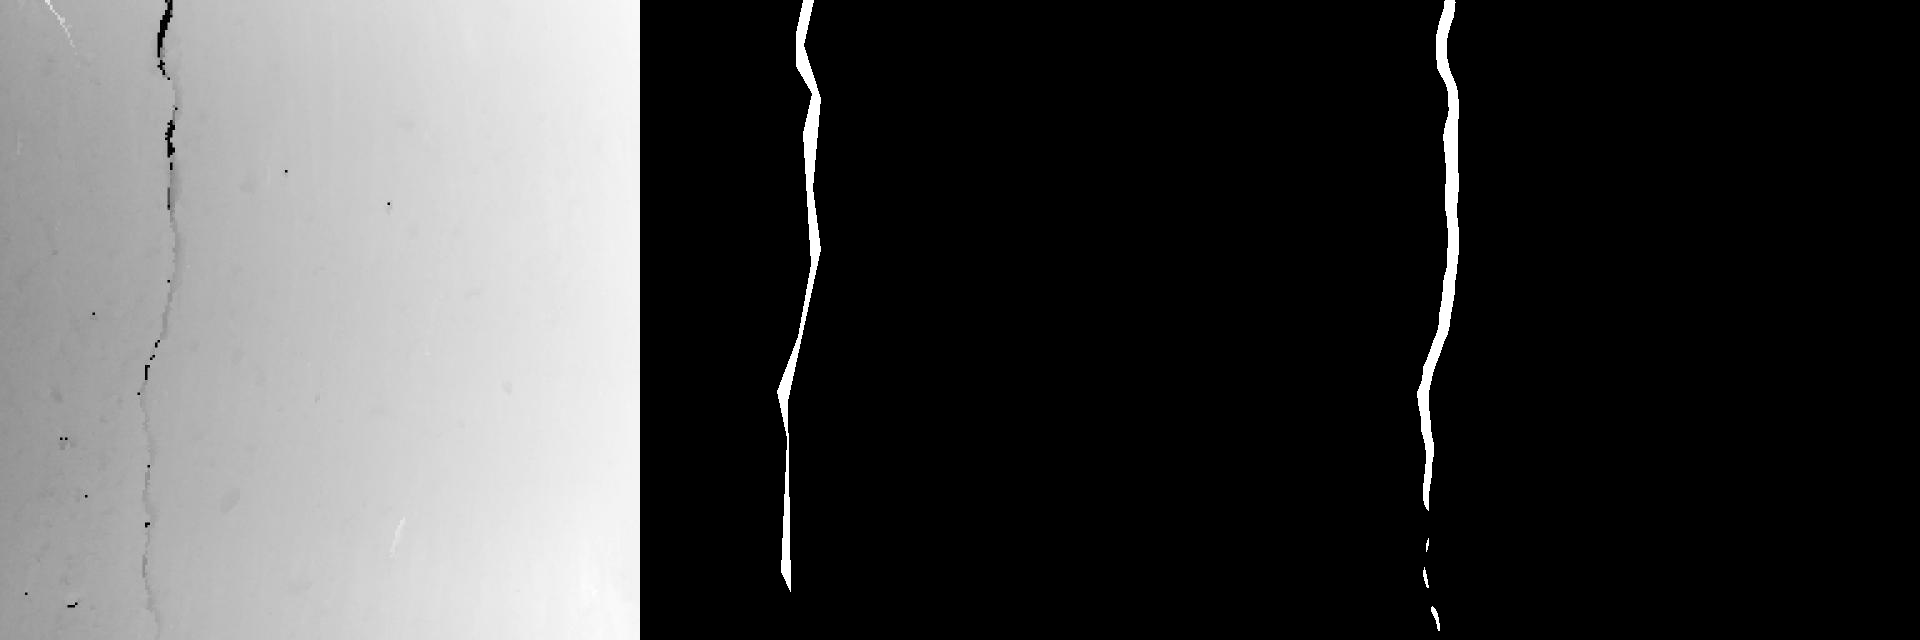

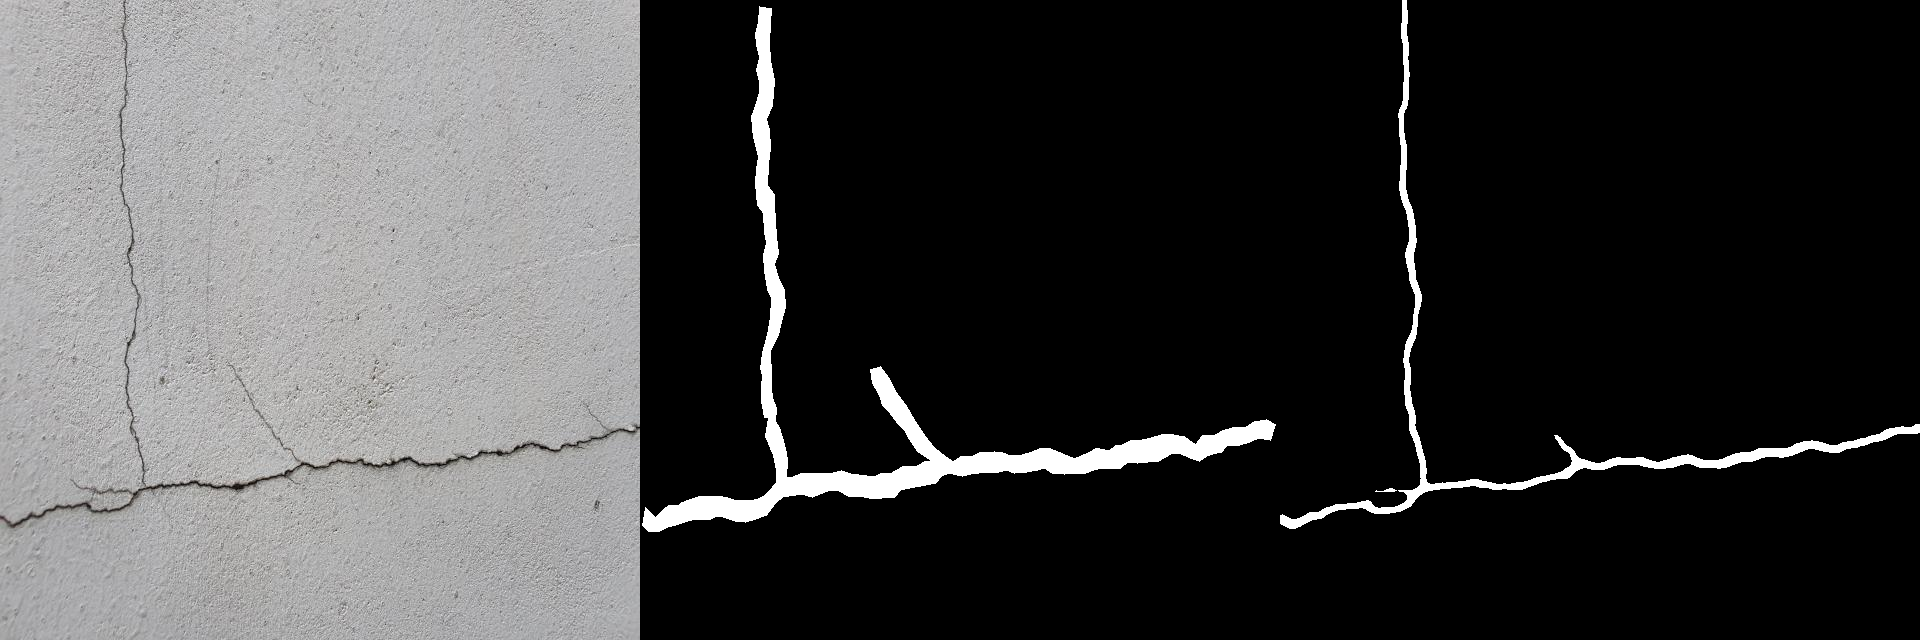


--- drywall examples (orig | GT | pred) ---


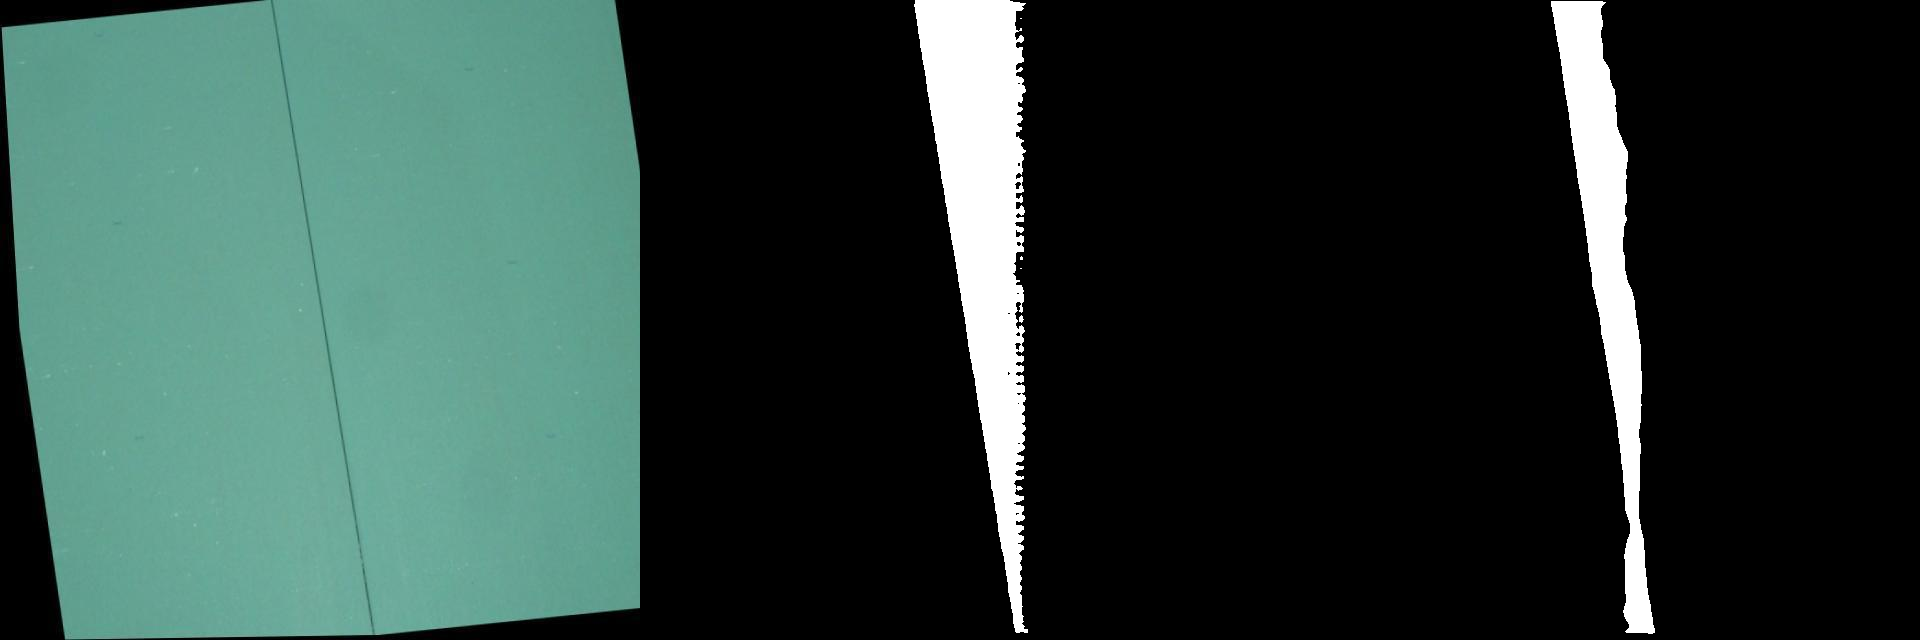

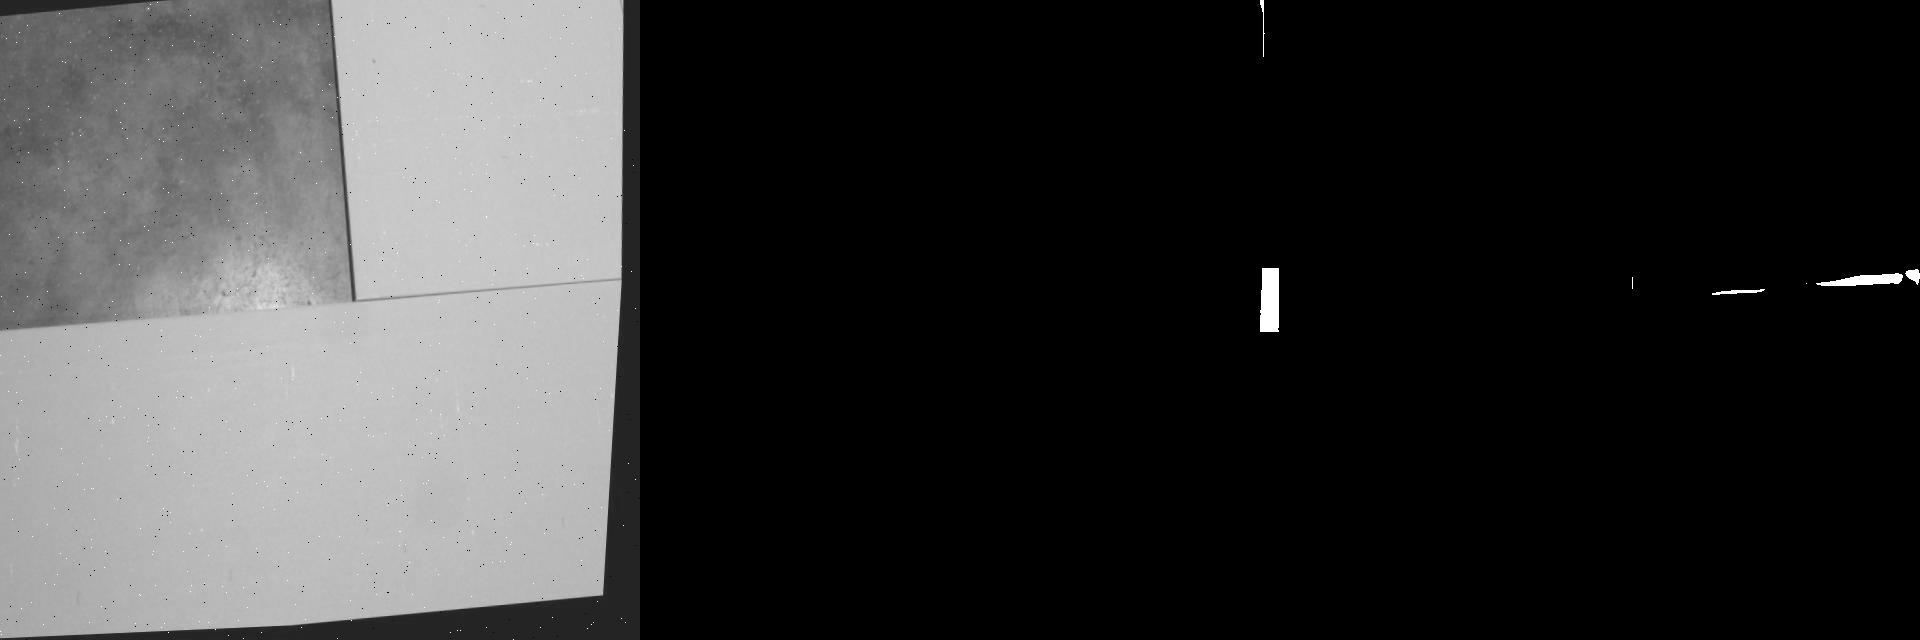

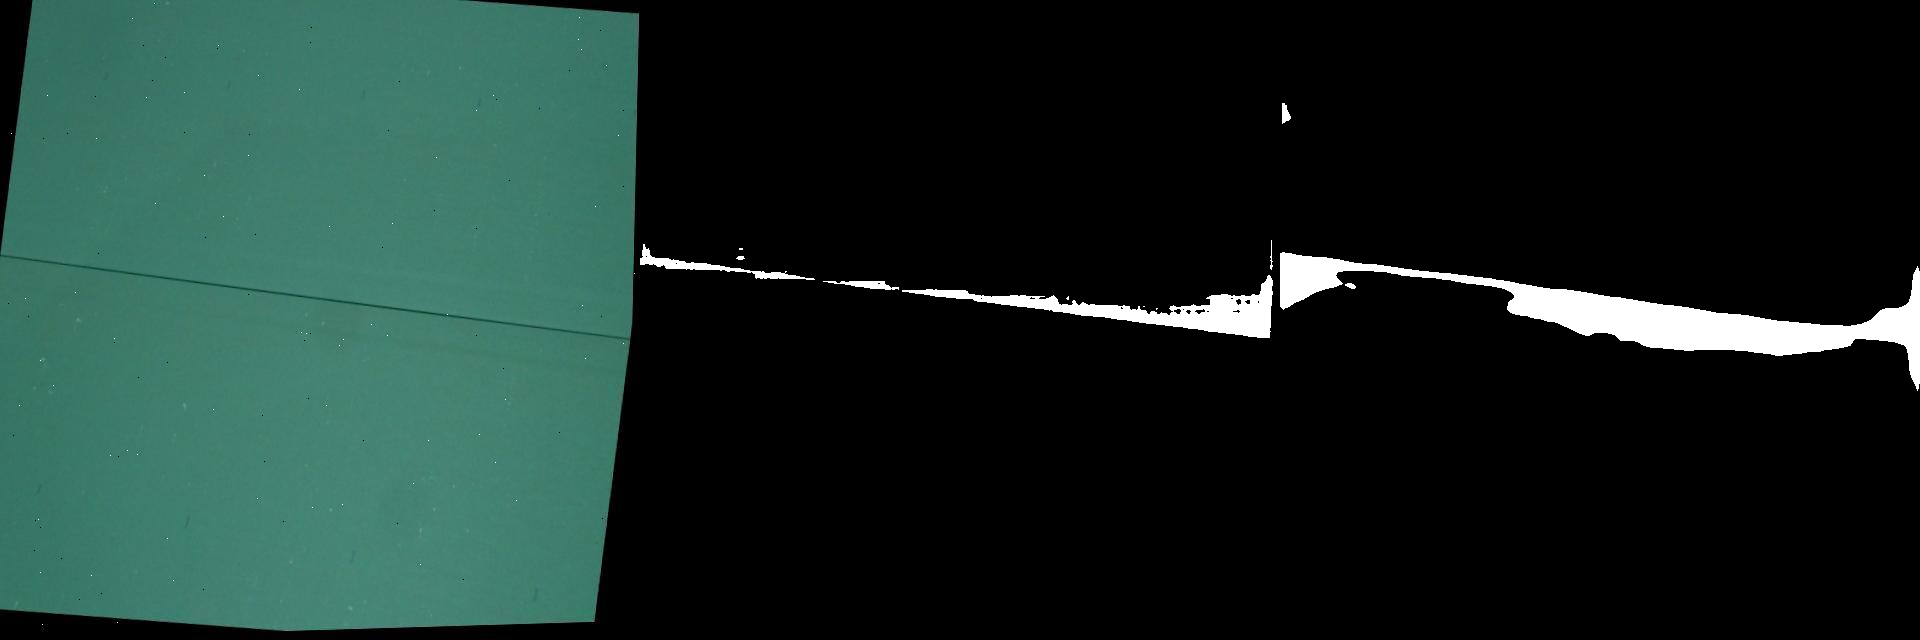

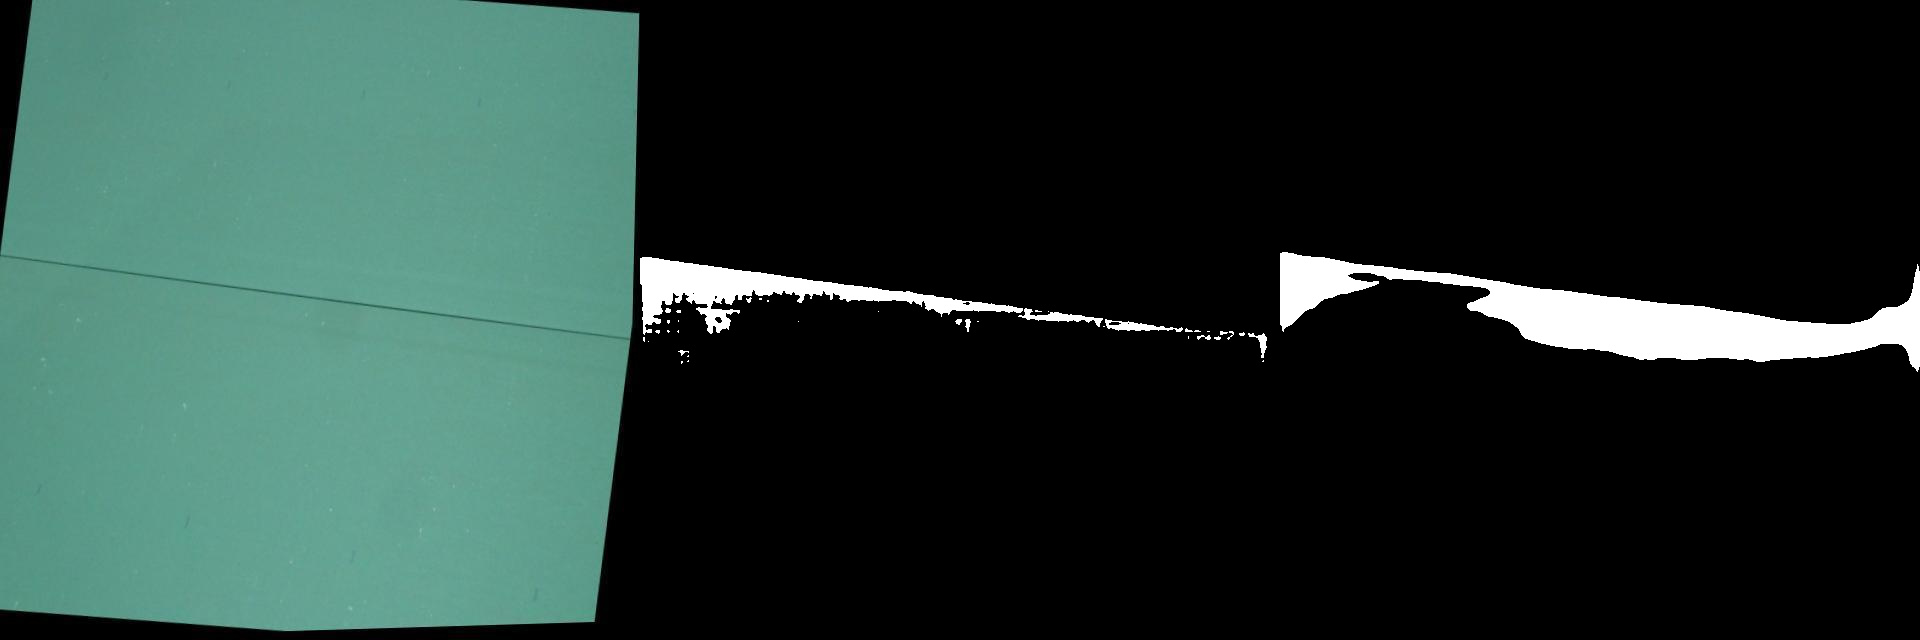

In [0]:
# Display a few example triplets
from PIL import Image
from IPython.display import display
import os


for name in ["cracks", "drywall"]:
    ex_dir = os.path.join(PROJECT_ROOT, "outputs", "phase5_resnet", f"{name}_examples")
    if not os.path.exists(ex_dir):
        print(f"{name}: no examples yet")
        continue
    files = sorted([f for f in os.listdir(ex_dir) if f.endswith(".png")])[:4]
    print(f"\n--- {name} examples (orig | GT | pred) ---")
    for f in files:
        display(Image.open(os.path.join(ex_dir, f)))